
# ================================================
# Tour Place Recommender System
# Reinforcement Learning (Q-Learning) Recommendation
# Student: Khalid Mahmud Joy | ID: 2022-3-60-159
# ================================================

In [ ]:
# Cell 2 - Import Libraries
import pandas as pd
import numpy as np
import random
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Cell 3 - Load Datasets
users_df        = pd.read_csv('Users.csv')
destinations_df = pd.read_csv('Destinations.csv')
ratings_df      = pd.read_csv('Ratings.csv')

print("Users shape:       ", users_df.shape)
print("Destinations shape:", destinations_df.shape)
print("Ratings shape:     ", ratings_df.shape)

Users shape:        (300, 6)
Destinations shape: (25, 9)
Ratings shape:      (2271, 3)


In [ ]:
# Cell 4 - Preprocessing
users_df        = users_df.dropna()
destinations_df = destinations_df.dropna()
ratings_df      = ratings_df.dropna()

users_df['Age']          = users_df['Age'].astype(int)
users_df['Budget-Level'] = users_df['Budget-Level'].astype(int)

destinations_df['Budget-Level'] = destinations_df['Budget-Level'].astype(int)
destinations_df['Avg-Rating']   = destinations_df['Avg-Rating'].astype(float)
ratings_df['Rating']            = ratings_df['Rating'].astype(int)

# Encode Dest-ID to integer index (Q-table needs numeric actions)
dest_ids        = destinations_df['Dest-ID'].tolist()
dest_id_to_idx  = {d: i for i, d in enumerate(dest_ids)}
idx_to_dest_id  = {i: d for d, i in dest_id_to_idx.items()}

user_ids        = users_df['User-ID'].tolist()
user_id_to_idx  = {u: i for i, u in enumerate(user_ids)}

print("Preprocessing complete!")
print(f"Total destinations (actions): {len(dest_ids)}")
print(f"Total users (states):         {len(user_ids)}")

Preprocessing complete!
Total destinations (actions): 25
Total users (states):         300


In [ ]:
# Cell 5 - Define Q-Learning Agent
class QLearningAgent:
    def __init__(self, state_space_size, action_space_size,
                 learning_rate=0.1, discount_factor=0.9, epsilon=0.1):
        # Initialize Q-table with zeros
        self.q_table        = np.zeros((state_space_size, action_space_size))
        self.learning_rate  = learning_rate
        self.discount_factor = discount_factor
        self.epsilon        = epsilon
        self.action_space_size = action_space_size

    def choose_action(self, state):
        # Epsilon-greedy: explore vs exploit
        if np.random.uniform(0, 1) < self.epsilon:
            # Explore: pick random destination
            return np.random.randint(self.action_space_size)
        else:
            # Exploit: pick best known action
            return np.argmax(self.q_table[state, :])

    def learn(self, state, action, reward, next_state, done):
        # Q-Learning update equation
        current_q  = self.q_table[state, action]
        max_next_q = np.max(self.q_table[next_state, :])
        target_q   = reward + self.discount_factor * max_next_q * (1 - done)
        self.q_table[state, action] += self.learning_rate * (target_q - current_q)

In [ ]:
# Cell 6 - Define Custom Tour Environment
class TourEnvironment:
    def __init__(self, users_df, destinations_df, ratings_df,
                 user_id_to_idx, dest_id_to_idx, idx_to_dest_id):

        self.users_df       = users_df
        self.destinations_df = destinations_df
        self.ratings_df     = ratings_df
        self.user_id_to_idx = user_id_to_idx
        self.dest_id_to_idx = dest_id_to_idx
        self.idx_to_dest_id = idx_to_dest_id

        self.num_users = len(users_df)
        self.num_dests = len(destinations_df)

        self.current_user_idx  = None
        self.recommended_dests = set()

    def reset(self, user_idx=None):
        # Pick a random user or specified user as the starting state
        if user_idx is None:
            self.current_user_idx = np.random.randint(self.num_users)
        else:
            self.current_user_idx = user_idx
        self.recommended_dests = set()
        return self.current_user_idx

    def step(self, action):
        dest_id   = self.idx_to_dest_id[action]
        user_id   = self.users_df.iloc[self.current_user_idx]['User-ID']

        # Check if real rating exists
        real_rating_row = self.ratings_df[
            (self.ratings_df['User-ID'] == user_id) &
            (self.ratings_df['Dest-ID'] == dest_id)
        ]

        if not real_rating_row.empty:
            rating = real_rating_row.iloc[0]['Rating']
        else:
            # Estimate based on avg-rating of destination
            dest_row = self.destinations_df[self.destinations_df['Dest-ID'] == dest_id]
            rating   = dest_row.iloc[0]['Avg-Rating'] if not dest_row.empty else 5.0

        # Reward shaping
        if rating >= 8:
            reward = 1.0        # strongly positive
        elif rating >= 6:
            reward = 0.3        # mildly positive
        elif rating >= 4:
            reward = -0.2       # neutral/slightly negative
        else:
            reward = -1.0       # negative

        # Penalize repeated recommendations
        if action in self.recommended_dests:
            reward -= 0.5
        self.recommended_dests.add(action)

        # Next state: stay with same user (single-user session)
        next_state = self.current_user_idx
        done       = len(self.recommended_dests) >= 10  # end after 10 recs

        return next_state, reward, done, rating

In [ ]:
# Cell 7 - Initialize Agent and Environment
state_space_size  = len(user_ids)    # one state per user
action_space_size = len(dest_ids)    # one action per destination

env   = TourEnvironment(users_df, destinations_df, ratings_df,
                        user_id_to_idx, dest_id_to_idx, idx_to_dest_id)

agent = QLearningAgent(state_space_size  = state_space_size,
                       action_space_size = action_space_size,
                       learning_rate     = 0.1,
                       discount_factor   = 0.9,
                       epsilon           = 0.1)

print(f"Q-table shape: {agent.q_table.shape}")
print(f"Agent initialized with epsilon={agent.epsilon} (10% exploration)")

Q-table shape: (300, 25)
Agent initialized with epsilon=0.1 (10% exploration)


In [ ]:
# Cell 8 - Training Loop
num_episodes    = 1000
total_rewards   = []

print("Training Q-Learning Agent...")
print("-" * 40)

for episode in range(num_episodes):
    state        = env.reset()          # random user each episode
    episode_reward = 0
    done         = False

    while not done:
        action               = agent.choose_action(state)
        next_state, reward, done, rating = env.step(action)
        agent.learn(state, action, reward, next_state, done)
        state          = next_state
        episode_reward += reward

    total_rewards.append(episode_reward)

    if (episode + 1) % 100 == 0:
        avg_reward = np.mean(total_rewards[-100:])
        print(f"  Episode {episode+1:4d} | Avg Reward (last 100): {avg_reward:.4f}")

print("\nTraining complete!")

Training Q-Learning Agent...
----------------------------------------
  Episode  100 | Avg Reward (last 100): 61.3730
  Episode  200 | Avg Reward (last 100): 57.4730
  Episode  300 | Avg Reward (last 100): 58.7740
  Episode  400 | Avg Reward (last 100): 58.8250
  Episode  500 | Avg Reward (last 100): 58.8730
  Episode  600 | Avg Reward (last 100): 58.8740
  Episode  700 | Avg Reward (last 100): 59.6550
  Episode  800 | Avg Reward (last 100): 56.5070
  Episode  900 | Avg Reward (last 100): 57.5550
  Episode 1000 | Avg Reward (last 100): 62.4230

Training complete!


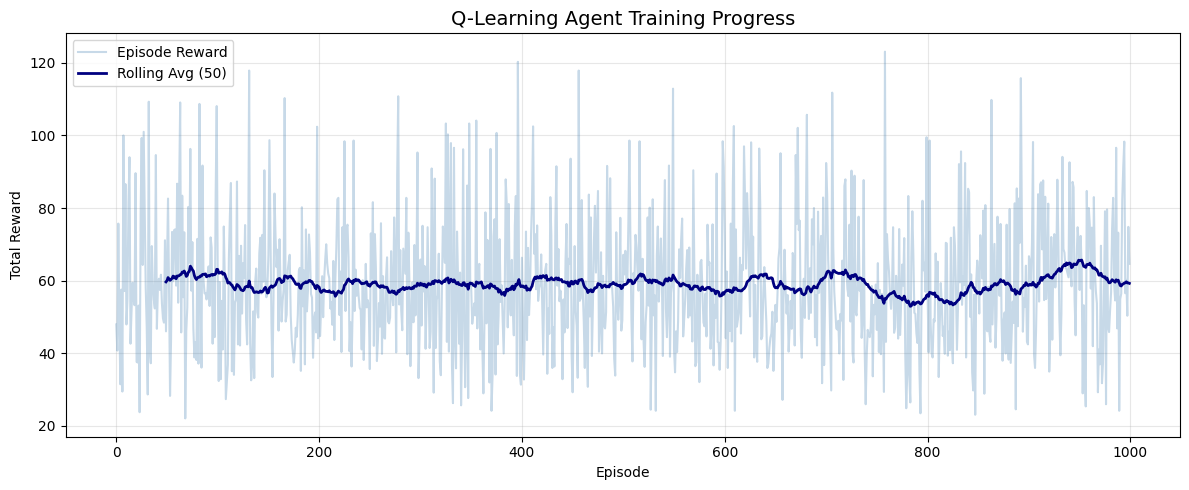

In [ ]:
# Cell 9 - Plot Training Rewards
import matplotlib.pyplot as plt

# Smooth rewards with rolling average
rolling_avg = pd.Series(total_rewards).rolling(window=50).mean()

plt.figure(figsize=(12, 5))
plt.plot(total_rewards, alpha=0.3, color='steelblue', label='Episode Reward')
plt.plot(rolling_avg,   color='navy',      linewidth=2, label='Rolling Avg (50)')
plt.title('Q-Learning Agent Training Progress', fontsize=14)
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Cell 10 - Recommendation Function Using Trained Q-Table
def rl_recommend(target_user_id, top_n=10):

    if target_user_id not in user_id_to_idx:
        print(f"User {target_user_id} not found.")
        return

    print(f"\n{'='*60}")
    print(f"  RL Recommendations for User: {target_user_id}")
    print(f"{'='*60}")

    user_row = users_df[users_df['User-ID'] == target_user_id].iloc[0]
    print(f"\n  User Profile:")
    print(f"  Division       : {user_row['Division']}")
    print(f"  Age            : {user_row['Age']}")
    print(f"  Travel Style   : {user_row['Travel-Style']}")
    print(f"  Preferred Type : {user_row['Preferred-Type']}")
    print(f"  Budget Level   : {user_row['Budget-Level']}")

    state = user_id_to_idx[target_user_id]

    # Already rated by this user
    already_rated_ids = ratings_df[ratings_df['User-ID'] == target_user_id]['Dest-ID'].tolist()
    already_rated_idx = {dest_id_to_idx[d] for d in already_rated_ids if d in dest_id_to_idx}

    # Get Q-values for this user state, exclude already-rated
    q_values = agent.q_table[state, :].copy()
    for idx in already_rated_idx:
        q_values[idx] = -999  # mask out

    # Get top-N actions by Q-value
    top_action_indices = np.argsort(q_values)[::-1][:top_n]

    recommendations = []
    for action_idx in top_action_indices:
        dest_id  = idx_to_dest_id[action_idx]
        dest_row = destinations_df[destinations_df['Dest-ID'] == dest_id]
        if dest_row.empty:
            continue
        dest_row = dest_row.iloc[0]
        recommendations.append({
            'Dest-ID'     : dest_id,
            'Name'        : dest_row['Name'],
            'Type'        : dest_row['Type'],
            'Division'    : dest_row['Division'],
            'Budget-Level': dest_row['Budget-Level'],
            'Best-Season' : dest_row['Best-Season'],
            'Avg-Rating'  : dest_row['Avg-Rating'],
            'Q-Value'     : round(q_values[action_idx], 4)
        })

    rec_df = pd.DataFrame(recommendations).reset_index(drop=True)
    rec_df.index += 1

    print(f"\n  Top {top_n} Recommended Destinations (by Q-Value):\n")
    display(rec_df)
    return rec_df

In [ ]:
# Cell 11 - Interactive RL Recommendation with Live Feedback
def rl_interactive(target_user_id, rounds=5):

    if target_user_id not in user_id_to_idx:
        print(f"User {target_user_id} not found.")
        return

    state       = user_id_to_idx[target_user_id]
    rated_idx   = set()

    print(f"\n{'='*60}")
    print(f"  Interactive RL Session for User: {target_user_id}")
    print(f"  The agent will recommend destinations one by one.")
    print(f"  Please rate each (1-10). Type 0 to stop.")
    print(f"{'='*60}\n")

    for round_num in range(1, rounds + 1):
        # Choose action (exploit best Q-value not yet rated)
        q_values = agent.q_table[state, :].copy()
        for idx in rated_idx:
            q_values[idx] = -999

        action   = np.argmax(q_values)
        dest_id  = idx_to_dest_id[action]
        dest_row = destinations_df[destinations_df['Dest-ID'] == dest_id].iloc[0]

        print(f"  Round {round_num}: Recommending → {dest_row['Name']} "
              f"({dest_row['Type']}, {dest_row['Division']}, "
              f"Budget Level: {dest_row['Budget-Level']}, "
              f"Avg Rating: {dest_row['Avg-Rating']})")

        try:
            user_rating = int(input(f"  Your rating for '{dest_row['Name']}' (1-10, 0 to stop): "))
        except ValueError:
            print("  Invalid input. Skipping.")
            continue

        if user_rating == 0:
            print("\n  Session ended by user.")
            break

        user_rating = max(1, min(10, user_rating))  # clamp to 1-10

        # Compute reward from user input
        if user_rating >= 8:
            reward = 1.0
        elif user_rating >= 6:
            reward = 0.3
        elif user_rating >= 4:
            reward = -0.2
        else:
            reward = -1.0

        rated_idx.add(action)
        next_state = state
        done       = round_num == rounds

        # Update Q-table with real feedback
        agent.learn(state, action, reward, next_state, done)
        print(f"  ✓ Rating received: {user_rating}/10 | Reward: {reward} | Q-table updated.\n")

    print("  Interactive session complete. Agent has learned from your feedback!")

In [ ]:
# Cell 12 - Run Recommendations
target_user = int(input("Enter User-ID: "))

print("\n--- Static RL Recommendations (from trained Q-table) ---")
rl_recommend(target_user_id=target_user, top_n=10)

print("\n--- Interactive RL Session (live feedback) ---")
rl_interactive(target_user_id=target_user, rounds=5)

Enter User-ID: 3

--- Static RL Recommendations (from trained Q-table) ---

  RL Recommendations for User: 3

  User Profile:
  Division       : Chattogram
  Age            : 55
  Travel Style   : Nature
  Preferred Type : Beach
  Budget Level   : 1

  Top 10 Recommended Destinations (by Q-Value):



,Dest-ID,Name,Type,Division,Budget-Level,Best-Season,Avg-Rating,Q-Value
1,BD001,Cox's Bazar,Beach,Chattogram,3,Winter,9.1,4.9906
2,BD005,Saint Martin's Island,Beach,Chattogram,4,Winter,9.2,2.3237
3,BD003,Sajek Valley,Hill,Chattogram,3,All,9.0,1.9032
4,BD008,Paharpur,Historical,Rajshahi,1,Winter,8.3,1.7536
5,BD009,Mahasthangarh,Historical,Rajshahi,1,Winter,8.0,1.6947
6,BD007,Kuakata,Beach,Barishal,2,Winter,8.5,1.3330
7,BD002,Sundarbans,Forest,Khulna,4,Winter,9.3,1.1297
8,BD023,Patenga Beach,Beach,Chattogram,1,All,7.6,1.0634
9,BD018,Tanguar Haor,Wetland,Sylhet,2,Monsoon,8.9,0.9140
10,BD016,Sylhet City,City,Sylhet,2,All,8.2,0.5689



--- Interactive RL Session (live feedback) ---

  Interactive RL Session for User: 3
  The agent will recommend destinations one by one.
  Please rate each (1-10). Type 0 to stop.

  Round 1: Recommending → Cox's Bazar (Beach, Chattogram, Budget Level: 3, Avg Rating: 9.1)
  Your rating for 'Cox's Bazar' (1-10, 0 to stop): 8
  ✓ Rating received: 8/10 | Reward: 1.0 | Q-table updated.

  Round 2: Recommending → Bhawal National Park (Nature, Dhaka, Budget Level: 1, Avg Rating: 7.5)
  Your rating for 'Bhawal National Park' (1-10, 0 to stop): 7
  ✓ Rating received: 7/10 | Reward: 0.3 | Q-table updated.

  Round 3: Recommending → Saint Martin's Island (Beach, Chattogram, Budget Level: 4, Avg Rating: 9.2)
  Your rating for 'Saint Martin's Island' (1-10, 0 to stop): 8
  ✓ Rating received: 8/10 | Reward: 1.0 | Q-table updated.

  Round 4: Recommending → Sajek Valley (Hill, Chattogram, Budget Level: 3, Avg Rating: 9.0)
  Your rating for 'Sajek Valley' (1-10, 0 to stop): 9
  ✓ Rating received: 9/

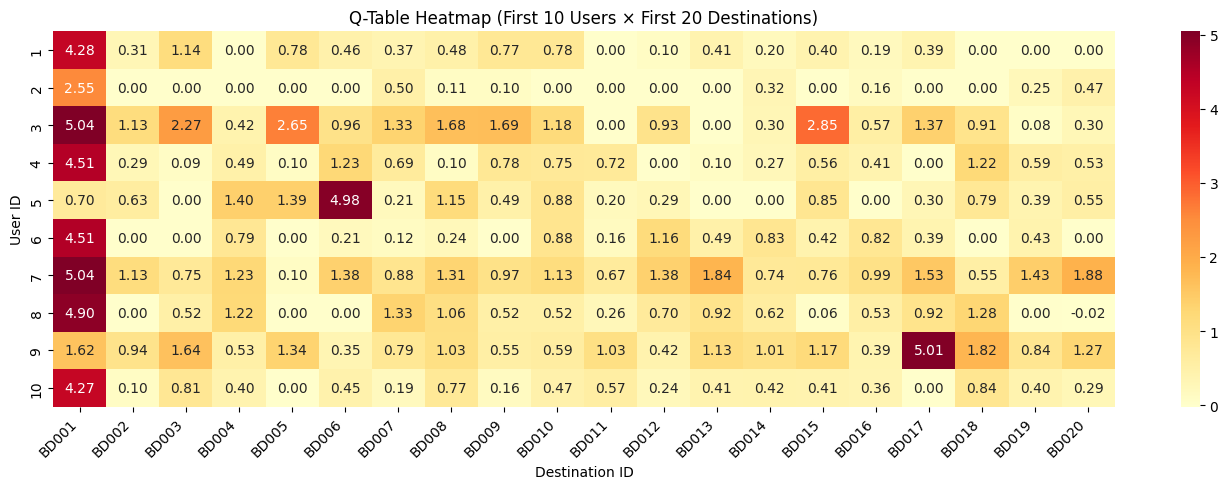

In [ ]:
# Cell 13 - Q-Table Heatmap (Sample)
import matplotlib.pyplot as plt
import seaborn as sns

# Show Q-values for first 10 users x first 20 destinations
sample_q = agent.q_table[:10, :20]

plt.figure(figsize=(14, 5))
sns.heatmap(sample_q,
            annot=True, fmt=".2f",
            cmap='YlOrRd',
            xticklabels=[idx_to_dest_id[i] for i in range(20)],
            yticklabels=[user_ids[i] for i in range(10)])
plt.title('Q-Table Heatmap (First 10 Users × First 20 Destinations)')
plt.xlabel('Destination ID')
plt.ylabel('User ID')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()